In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
import os
data_dir = '../data' if os.path.exists('../data') else ('data' if os.path.exists('data') else '.')
csv_path = os.path.join(data_dir, 'creditcard.csv') if os.path.exists(os.path.join(data_dir, 'creditcard.csv')) else 'creditcard.csv'
df = pd.read_csv(csv_path)


In [3]:
#preview data
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

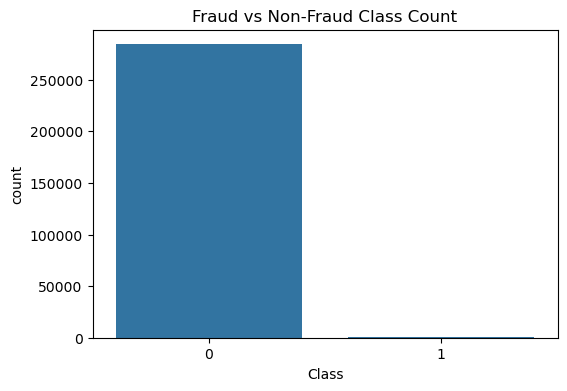

In [8]:
# Class distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title('Fraud vs Non-Fraud Class Count')
plt.show()

In [9]:
# Correlation Matrix

corr_matrix = df.corr() 
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

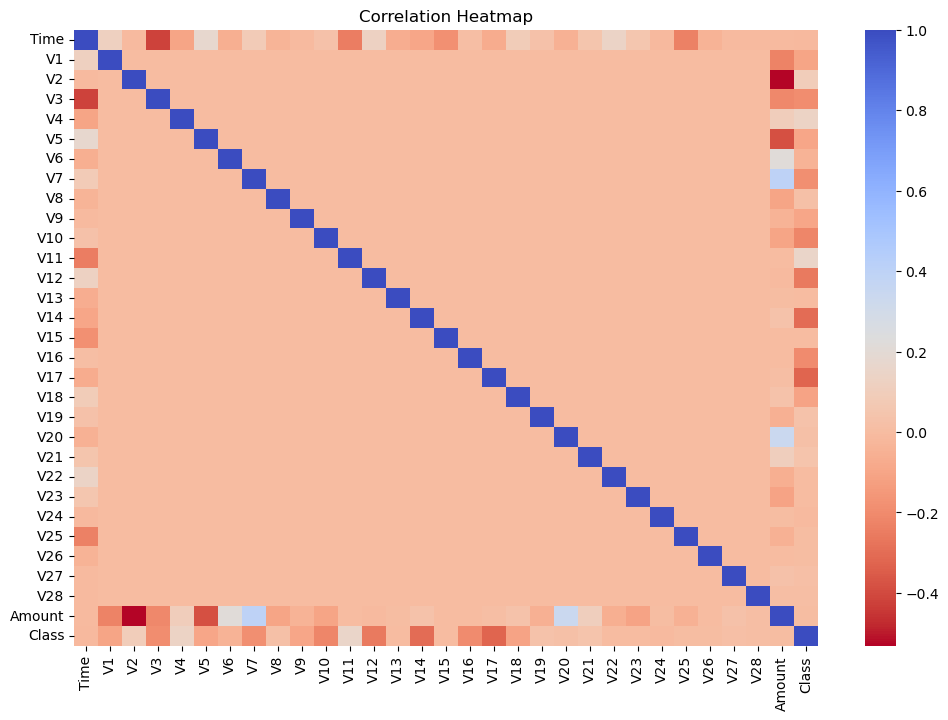

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm_r', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
# Feature Scaling
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['Scaled_Time'] = scaler.fit_transform(df[['Time']])

In [13]:
# Drop original 'Time' and 'Amount'
df = df.drop(['Time', 'Amount'], axis=1)

In [14]:
# Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
#20% of data goes to testing, 80% to training

# Model Building
# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, roc_auc_score, roc_curve

In [17]:
lr = LogisticRegression(max_iter=1000)

In [18]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred_lr = lr.predict(X_test)

In [20]:
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [22]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)

In [24]:
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# Model Evaluation

In [25]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[56859     5]
 [   18    80]]


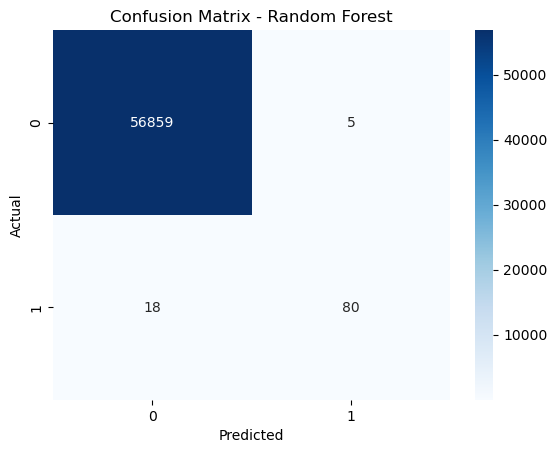

In [26]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
y_probs = rf.predict_proba(X_test)[:, 1]

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)#False Positive Rate (FPR) and True Positive Rate (TPR)
roc_score = roc_auc_score(y_test, y_probs)#ROC Curve (Receiver Operating Characteristic Curve)

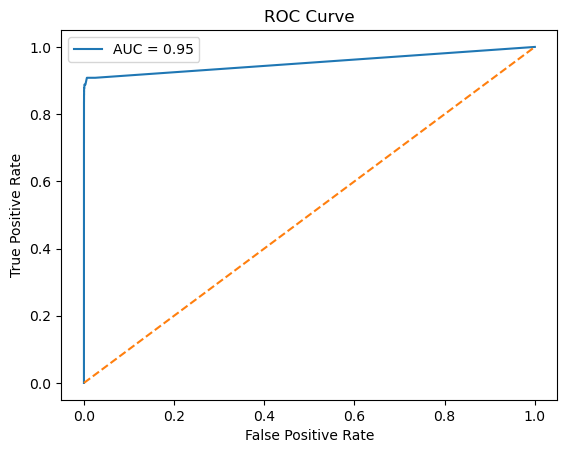

In [29]:
plt.plot(fpr, tpr, label=f'AUC = {roc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [30]:
print(accuracy_score(y_test, y_pred_rf))

0.9995962220427653


In [31]:
print(accuracy_score(y_test, y_pred_lr))

0.9991573329588147
